In [2]:
from qiskit.synthesis import adder_ripple_c04
from common import *
n = 2

[[1809.09732] Quantum Circuit Designs of Integer Division Optimizing T-count and T-depth](https://arxiv.org/abs/1809.09732)

In [3]:
a = QuantumRegister(2, name="A")
b = QuantumRegister(2, name="B")
q = QuantumRegister(2, name="Q")
r = QuantumRegister(2, name="R")
ctrl = QuantumRegister(1, name="CTRL")
anc = QuantumRegister(1, name="Ancillas")

# Subtractor
Built with the r25 adder: [[2501.16802] Ancilla-free Quantum Adder with Sublinear Depth](https://arxiv.org/abs/2501.16802). But the carry-out is removed

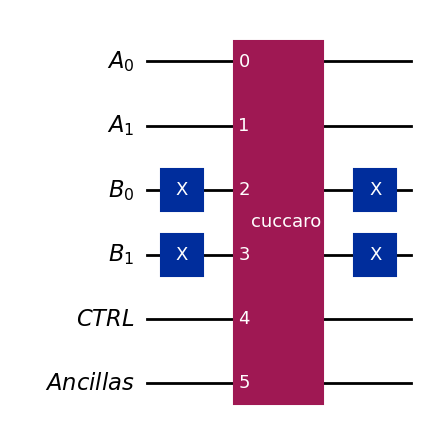

In [7]:
# ctrl is 1 iff b - a < 0, which is the case iff the most significant bit of b - a is 1
# Only for divider
subtractor_neg_dect = QuantumCircuit(a, b, ctrl, anc, name="Subtractor (Neg)")
subtractor_neg_dect.x(b)
cuccaro_qc = adder_ripple_c04(n)
cuccaro_qc.name = "cuccaro"
subtractor_neg_dect.append(cuccaro_qc, a[:] + b[:] + ctrl[:] + anc[:])
subtractor_neg_dect.x(b)
subtractor_neg_dect.draw("mpl")

In [10]:
test_circuit(
    subtractor_neg_dect,
    list(range(2**n)), a,
    list(range(2**n)), b,
    [a, b, ctrl, anc],
    lambda a, b: (b - a) % 2**n,
    (2, n+2),
)

Initial state: 000000
Final state:   000000
Initial state: 000100
Final state:   000100
Initial state: 001000
Final state:   001000
Initial state: 001100
Final state:   001100
Initial state: 000001
Final state:   011101
Initial state: 000101
Final state:   000001
Initial state: 001001
Final state:   000101
Initial state: 001101
Final state:   001001
Initial state: 000010
Final state:   011010
Initial state: 000110
Final state:   011110
Initial state: 001010
Final state:   000010
Initial state: 001110
Final state:   000110
Initial state: 000011
Final state:   010111
Initial state: 000111
Final state:   011011
Initial state: 001011
Final state:   011111
Initial state: 001111
Final state:   000011
Total wrongs: 0
Total tests: 16


# Conditional Adder

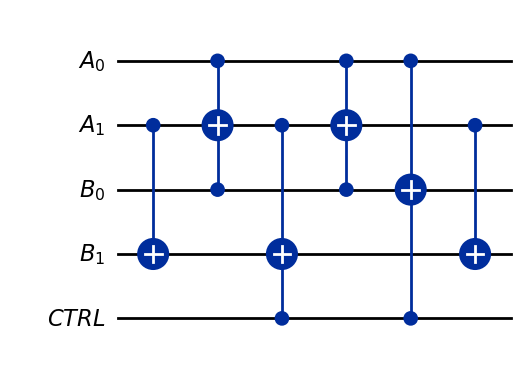

In [64]:
def conditional_adder(a, b, ctrl) -> QuantumCircuit:
    # In-place: b = b + a if ctrl == 1, else b unchanged
    qc = QuantumCircuit(a, b, ctrl, name="ConditionalAdder")

    for i in range(1, n):
        qc.cx(a[i], b[i])

    
    for i in range(n-1):
        qc.ccx(a[i], b[i], a[i+1])
    
    for i in range(n-2, -1, -1):
        qc.ccx(ctrl, a[i+1], b[i+1])
        qc.ccx(a[i], b[i], a[i+1])

    qc.ccx(ctrl, a[0], b[0])
    
    
    for i in range(1, n):
        qc.cx(a[i], b[i])
    
    return qc

conditional_adder(a, b, ctrl).draw("mpl")

In [65]:
# Test conditional adder
# ctrl 0
test_circuit(
    conditional_adder(a, b, ctrl),
    list(range(2**n)), a,
    list(range(2**n)), b,
    [a, b, ctrl],
    lambda a, b: b,
    (1, n+1),
)

Initial state: 00000
Final state:   00000
Initial state: 00100
Final state:   00100
Initial state: 01000
Final state:   01000
Initial state: 01100
Final state:   01100
Initial state: 00001
Final state:   00001
Initial state: 00101
Final state:   00101
Initial state: 01001
Final state:   01001
Initial state: 01101
Final state:   01101
Initial state: 00010
Final state:   00010
Initial state: 00110
Final state:   00110
Initial state: 01010
Final state:   01010
Initial state: 01110
Final state:   01110
Initial state: 00011
Final state:   00011
Initial state: 00111
Final state:   00111
Initial state: 01011
Final state:   01011
Initial state: 01111
Final state:   01111
Total wrongs: 0
Total tests: 16


In [68]:
# ctrl 1
conditional_adder_ctrl = QuantumCircuit(a, b, ctrl, name="ConditionalAdderCtrl")
conditional_adder_ctrl.x(ctrl)
conditional_adder_ctrl.append(conditional_adder(a, b, ctrl), a[:] + b[:] + ctrl[:])
test_circuit(
    conditional_adder_ctrl,
    list(range(2**n)), a,
    list(range(2**n)), b,
    [a, b, ctrl],
    lambda a, b: (a + b) % 2**n,
    (1, n+1),
)

Initial state: 00000
Final state:   10000
Initial state: 00100
Final state:   10100
Initial state: 01000
Final state:   11000
Initial state: 01100
Final state:   11100
Initial state: 00001
Final state:   10101
Initial state: 00101
Final state:   11001
Initial state: 01001
Final state:   11101
Initial state: 01101
Final state:   10001
Initial state: 00010
Final state:   11010
Initial state: 00110
Final state:   11110
Initial state: 01010
Final state:   10010
Initial state: 01110
Final state:   10110
Initial state: 00011
Final state:   11111
Initial state: 00111
Final state:   10011
Initial state: 01011
Final state:   10111
Initial state: 01111
Final state:   11011
Total wrongs: 0
Total tests: 16


# Iteration

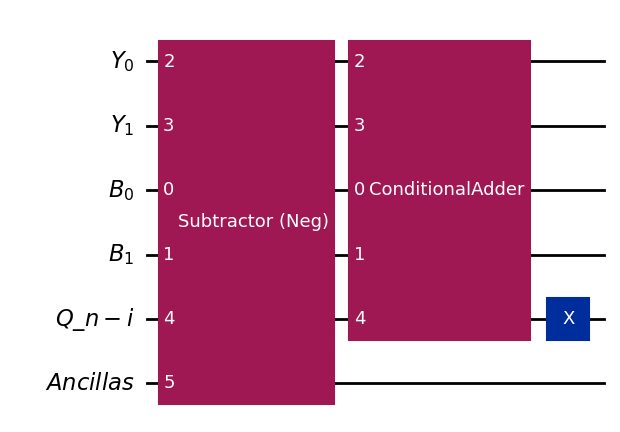

In [69]:
y = QuantumRegister(n, name="Y")
q_next = QuantumRegister(1, name="Q_{n-i}")
iteration = QuantumCircuit(y, b, q_next, anc, name="Iteration")
# q_next is the control which will be 1 if negative
iteration.append(subtractor_neg_dect, b[:] + y[:] + q_next[:] + anc[:])
conditional_adder_qc = conditional_adder(b, y, q_next)
iteration.append(conditional_adder_qc, b[:] + y[:] + q_next[:])
# 0 if negative, 1 if non-negative
iteration.x(q_next)
iteration.draw("mpl")

In [72]:
test_circuit(
    iteration,
    list(range(2**n)), y,
    list(range(2**n)), b,
    [y, b, q_next, anc],
    lambda y, b: y - b if y >= b else y,
    (4, 6)
)

Initial state: 000000
Final state:   010000
Initial state: 000100
Final state:   000100
Initial state: 001000
Final state:   001000
Initial state: 001100
Final state:   001100
Initial state: 000001
Final state:   010001
Initial state: 000101
Final state:   010100
Initial state: 001001
Final state:   001001
Initial state: 001101
Final state:   001101
Initial state: 000010
Final state:   010010
Initial state: 000110
Final state:   010101
Initial state: 001010
Final state:   011000
Initial state: 001110
Final state:   001110
Initial state: 000011
Final state:   010011
Initial state: 000111
Final state:   010110
Initial state: 001011
Final state:   011001
Initial state: 001111
Final state:   011100
Total wrongs: 0
Total tests: 16


In [52]:
import importlib
import common
importlib.reload(common)
from common import *

In [73]:
iteration_test = QuantumCircuit(y, b, q_next, anc)
iteration_test.x(b[0])
iteration_test.append(iteration, y[:] + b[:] + q_next[:] + anc[:])
expanded = iteration_test.decompose(gates_to_decompose=[iteration.name])
debug_circuit(expanded)

Applying instruction: CircuitInstruction(operation=Instruction(name='x', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "B"), index=0>,), clbits=())
State after x: Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j],
            dims=(2, 2, 2, 2, 2, 2))
Probabilities: {'000100': 1.0}

Applying instruction: CircuitInstruction(operation=Instruction(name='Subtractor (Neg)', num_qubits=6, n

# Divider

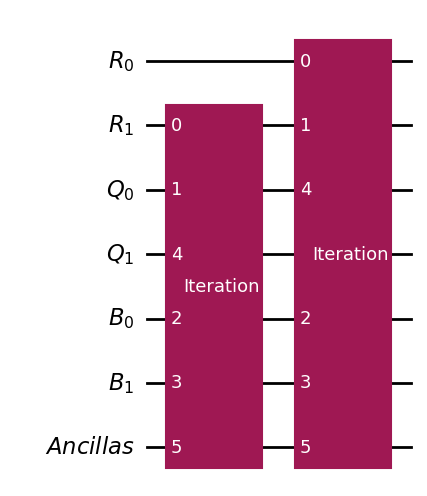

In [74]:
divider_qc = QuantumCircuit(r, q, b, anc)
# division of a by b
# r should be set to a, q should be set to 0, b should be set to b
for i in (1, 0):
    divider_qc.append(iteration, r[i:] + q[:i] + b[:] + [q[i]] + anc[:])

divider_qc.draw("mpl")

In [75]:
for a_val in range(1, 4):
    for b_val in range(1, a_val+1):
        print(f"Testing {a_val} // {b_val} and {a_val} % {b_val}")
        q_val, r_val = get_answer(divider_qc, a_val, r, b_val, b, (r, q, b, anc), r[:] + q[:] + b[:] + anc[:], [(3, 5), (5, 7)])
        assert q_val == a_val // b_val, f"Failed for {a_val} // {b_val}: got {q_val}"
        assert r_val == a_val % b_val, f"Failed for {a_val} % {b_val}: got {r_val}"

Testing 1 // 1 and 1 % 1
Initial state: 0010001
Final state:   0010100
Testing 2 // 1 and 2 % 1
Initial state: 0010010
Final state:   0011000
Testing 2 // 2 and 2 % 2
Initial state: 0100010
Final state:   0100100
Testing 3 // 1 and 3 % 1
Initial state: 0010011
Final state:   0011100
Testing 3 // 2 and 3 % 2
Initial state: 0100011
Final state:   0100101
Testing 3 // 3 and 3 % 3
Initial state: 0110011
Final state:   0110100


# Inspect

Size: 48
Toffoli count: 16
CZ count: 238
T count: 112
Depth: 36
Toffoli depth: 16
CZ depth: 203
T depth: 64
Width: 7
Algebraic connectivity: 2.7856802566224674


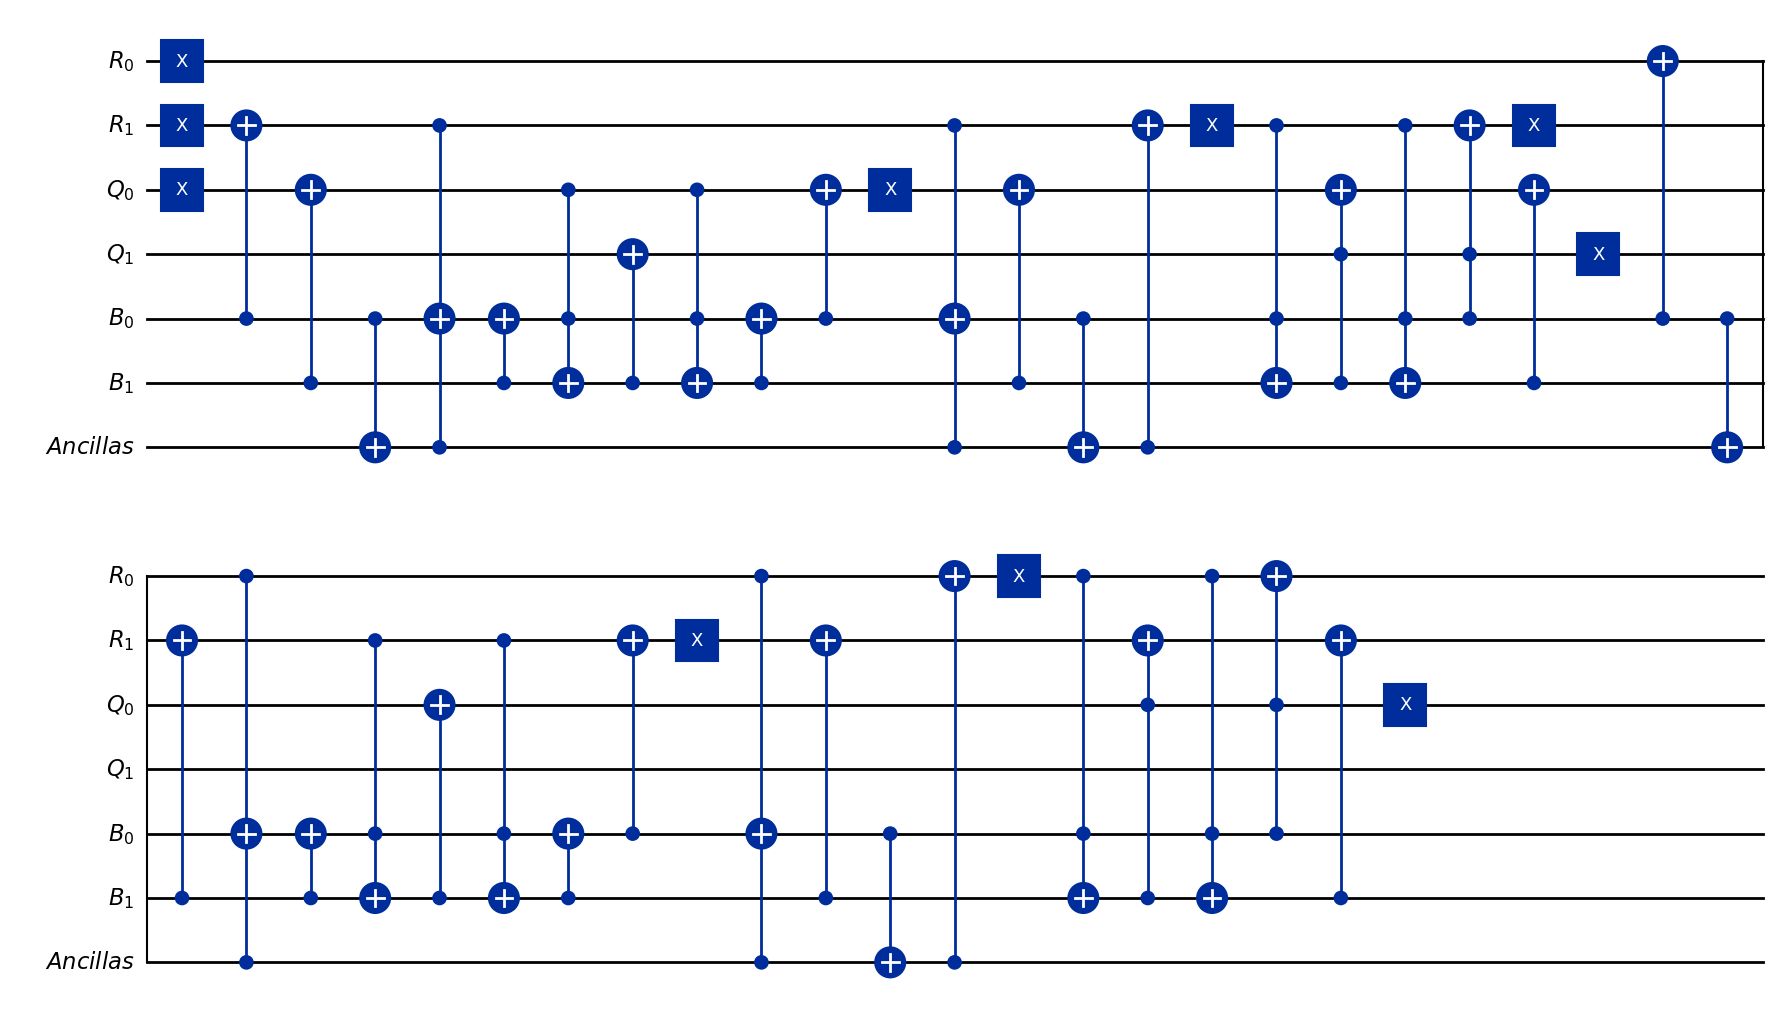

In [78]:
expanded = divider_qc.decompose(gates_to_decompose=[iteration.name, subtractor_neg_dect.name, conditional_adder_qc.name, cuccaro_qc.name, "MAJ", "UMA"], reps=4)
print_metrics(expanded)
expanded.draw(output="mpl")

# Run

01 / 01 = 01 r00

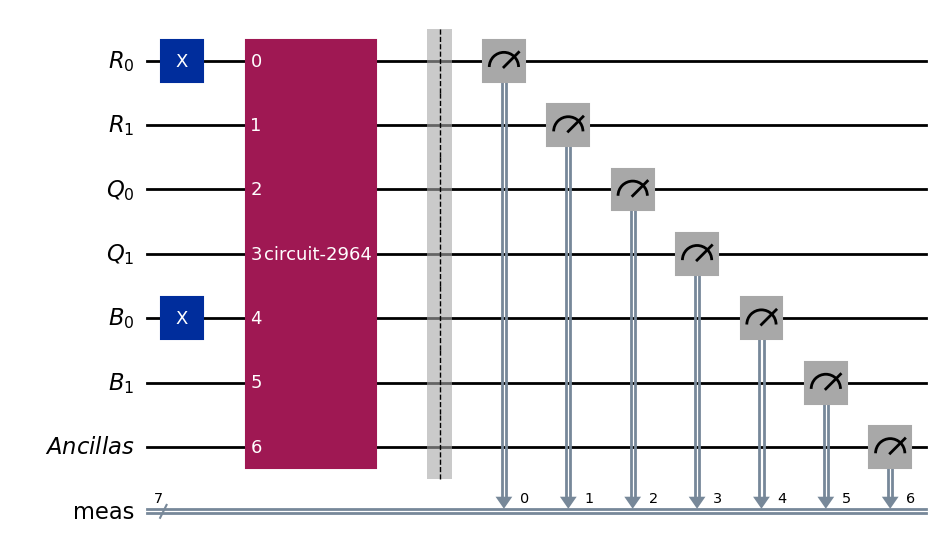

In [80]:
test_0 = QuantumCircuit(r, q, b, anc)
test_0.x(r[0])
test_0.x(b[0])
test_0.append(divider_qc, r[:] + q[:] + b[:] + anc[:])
test_0.measure_all()
test_0.draw(output="mpl")

In [82]:
backend_sampler.options.default_shots = 2**11
isa_circuit_mult_qiskit = pm.run(test_0)
job = backend_sampler.run([isa_circuit_mult_qiskit])
print(f"Job ID: {job.job_id()}")

Job ID: d9aldau6hjac73fejq00


Top 10 results:
{'0010100': 531, '0010001': 135, '0011011': 98, '0011110': 71, '0010110': 67, '1000100': 67, '0000100': 59, '0010011': 36, '1000000': 34, '0011100': 30}
Number of keys: 126
Number of shots: 2048
Expected result 0010100: 531
Probability: 0.2593


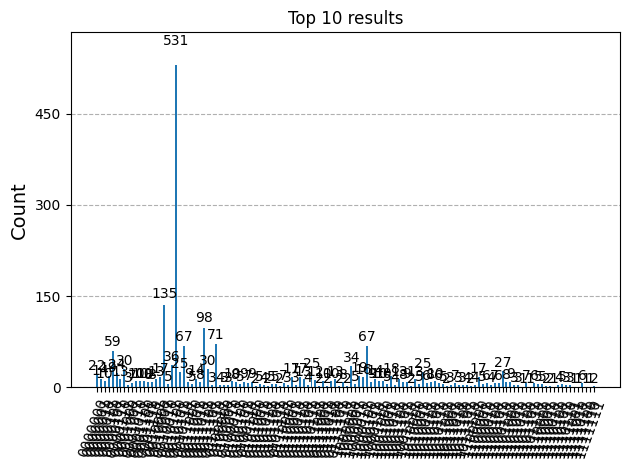

In [83]:
inspect_results(job, "0010100")

11 / 11 = 1 r0

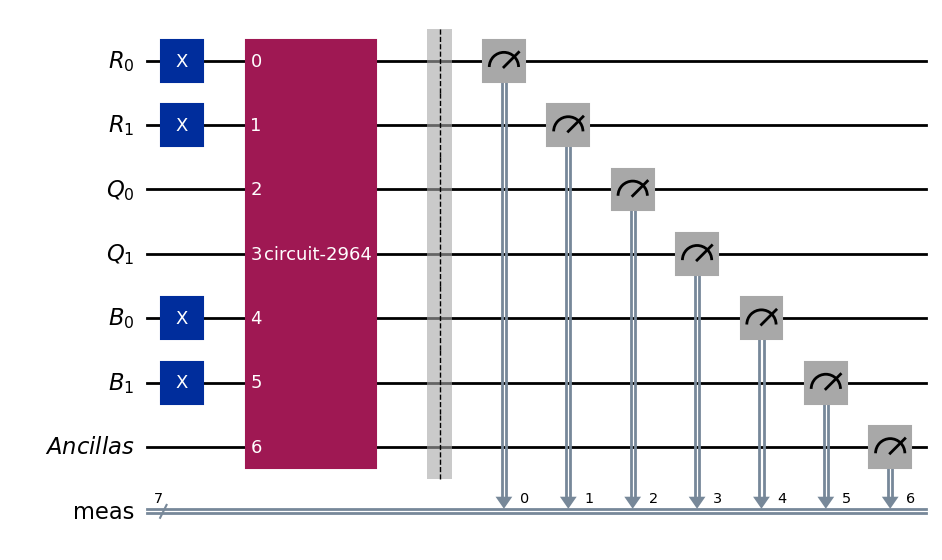

In [84]:
test_1 = QuantumCircuit(r, q, b, anc)
test_1.x(r)
test_1.x(b)
test_1.append(divider_qc, r[:] + q[:] + b[:] + anc[:])
test_1.measure_all()
test_1.draw(output="mpl")

In [85]:
isa_circuit_mult_qiskit = pm.run(test_1)
job_1 = backend_sampler.run([isa_circuit_mult_qiskit])
print(f"Job ID: {job.job_id()}")

Job ID: d9aldau6hjac73fejq00


Top 10 results:
{'0110100': 398, '0110011': 162, '0111110': 90, '0010110': 72, '0110110': 65, '1100100': 60, '0010011': 54, '0111001': 47, '0100100': 45, '1100000': 33}
Number of keys: 128
Number of shots: 2048
Expected result 0110100: 398
Probability: 0.1943


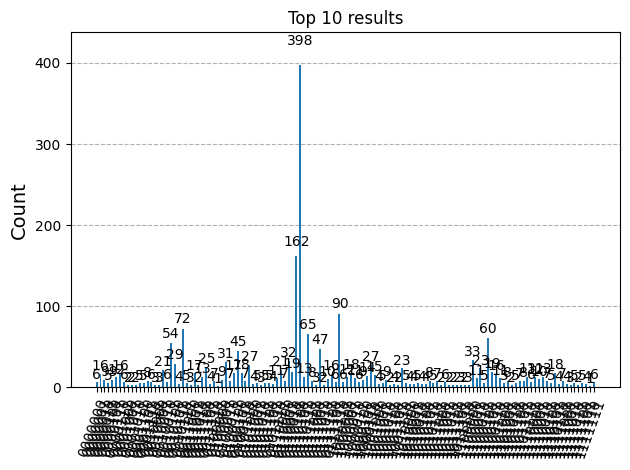

In [86]:
inspect_results(job_1, "0110100")